<a href="https://colab.research.google.com/github/karrixxa/DEEP_HousingPrices/blob/main/DEEPTeam2HousingPricesSubmission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold

from sklearn.tree import plot_tree
#Remember to load the datasets into the colab
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")



Mounted at /content/drive


# Pre Processing and Cleaning

In [ ]:
# Helpers
#calculate model error; rmse measures absolute price error/rmsle measures log scaled error
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmsle(y_true, y_pred):
    y_true_c = np.clip(y_true, 0, None)
    y_pred_c = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true_c, y_pred_c))

#wraps any regressor so it trains on log(Saleprice) and automatically converts predictions back to real dollars
#if skewed
#many regression assume (Lin, lasso, SVR) normally distributed + model residuals have constant variance, so logging
#makes distribution closer to normal whcih helps models fit better
#it models relative chances not absolute (percentage errors instead of raw dollar differences)
#A $10,000 error on a $100,000 home (10%) is much worse than a $10,000 error on a $1,000,000 home (1%)

def ttr(model):
    return TransformedTargetRegressor(regressor=model, func=np.log1p, inverse_func=np.expm1)

#one hot encoder (Categorical to dummy)
def make_ohe():
    try:
        return OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)
# Dropping columns with high na (>365, or 25% of the dataset)
# print(train[['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']].isna().sum())
columns_to_drop = ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
train = train.drop(columns=columns_to_drop)
test = test.drop(columns=columns_to_drop)

# Imputing some columns with more logical values
bsmt_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
for bsmt_col in bsmt_cols:
  train[bsmt_col]=train[bsmt_col].fillna("None")
  test[bsmt_col]=test[bsmt_col].fillna("None")

garage_cols= ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]
for garage_col in garage_cols:
  train[garage_col]=train[garage_col].fillna("None")
  test[garage_col]=test[garage_col].fillna("None")

train["GarageYrBlt"]=train["GarageYrBlt"].fillna(0)
train["LotFrontage"]=train["LotFrontage"].fillna(0)
test["GarageYrBlt"]=test["GarageYrBlt"].fillna(0)
test["LotFrontage"]=test["LotFrontage"].fillna(0)

# Data + preprocessing
y = train["SalePrice"].copy()
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["SalePrice", "Id"]]
cat_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()
X = train[num_cols + cat_cols].copy()
X_test= test[num_cols + cat_cols].copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=341)

#preprocessing
#numeric, fill missing w median, scales features
#categorical, fill missing w most freq, dummy variables
#combine both sub piplines, so transformed simulatenously

#because data is skewed, median is used instead of mean
numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
categorical_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("ohe", make_ohe())])

preprocess = ColumnTransformer([("num", numeric_pipe, num_cols), ("cat", categorical_pipe, cat_cols)], remainder="drop")

def make_pipe(base_model):
    return Pipeline([("prep", preprocess), ("ttr", ttr(base_model))])

# Visualizations

Mean Sale Price Relative to 2006 by Year
         SalePrice
YrSold            
2006    100.000000
2007    101.924790
2008     97.157691
2009     98.292323
2010     97.175678


Text(0.5, 1.0, 'Median House Prices relative to 2006')

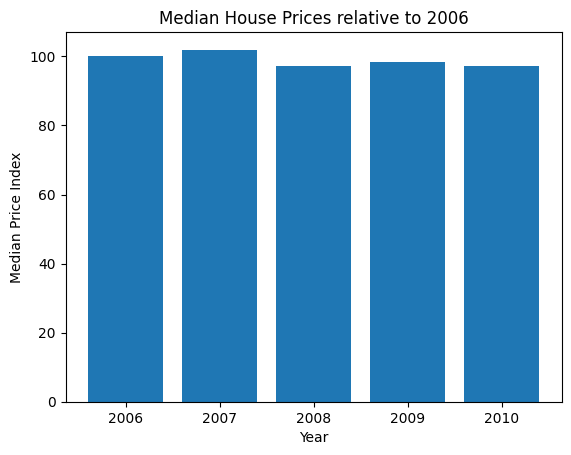

In [ ]:
print("Mean Sale Price Relative to 2006 by Year")
house_prices_in_2006=train[['YrSold','SalePrice']].loc[train['YrSold']==2006]
mean_price_in_2006=house_prices_in_2006['SalePrice'].mean()
mean_price_by_year=train[['YrSold','SalePrice']].groupby('YrSold').mean()/mean_price_in_2006*100
print(mean_price_by_year)
#Let 2006 be the base year for the index

plt.bar(mean_price_by_year.index, mean_price_by_year['SalePrice'])
plt.xlabel('Year')
plt.ylabel('Median Price Index')
plt.title('Median House Prices relative to 2006')

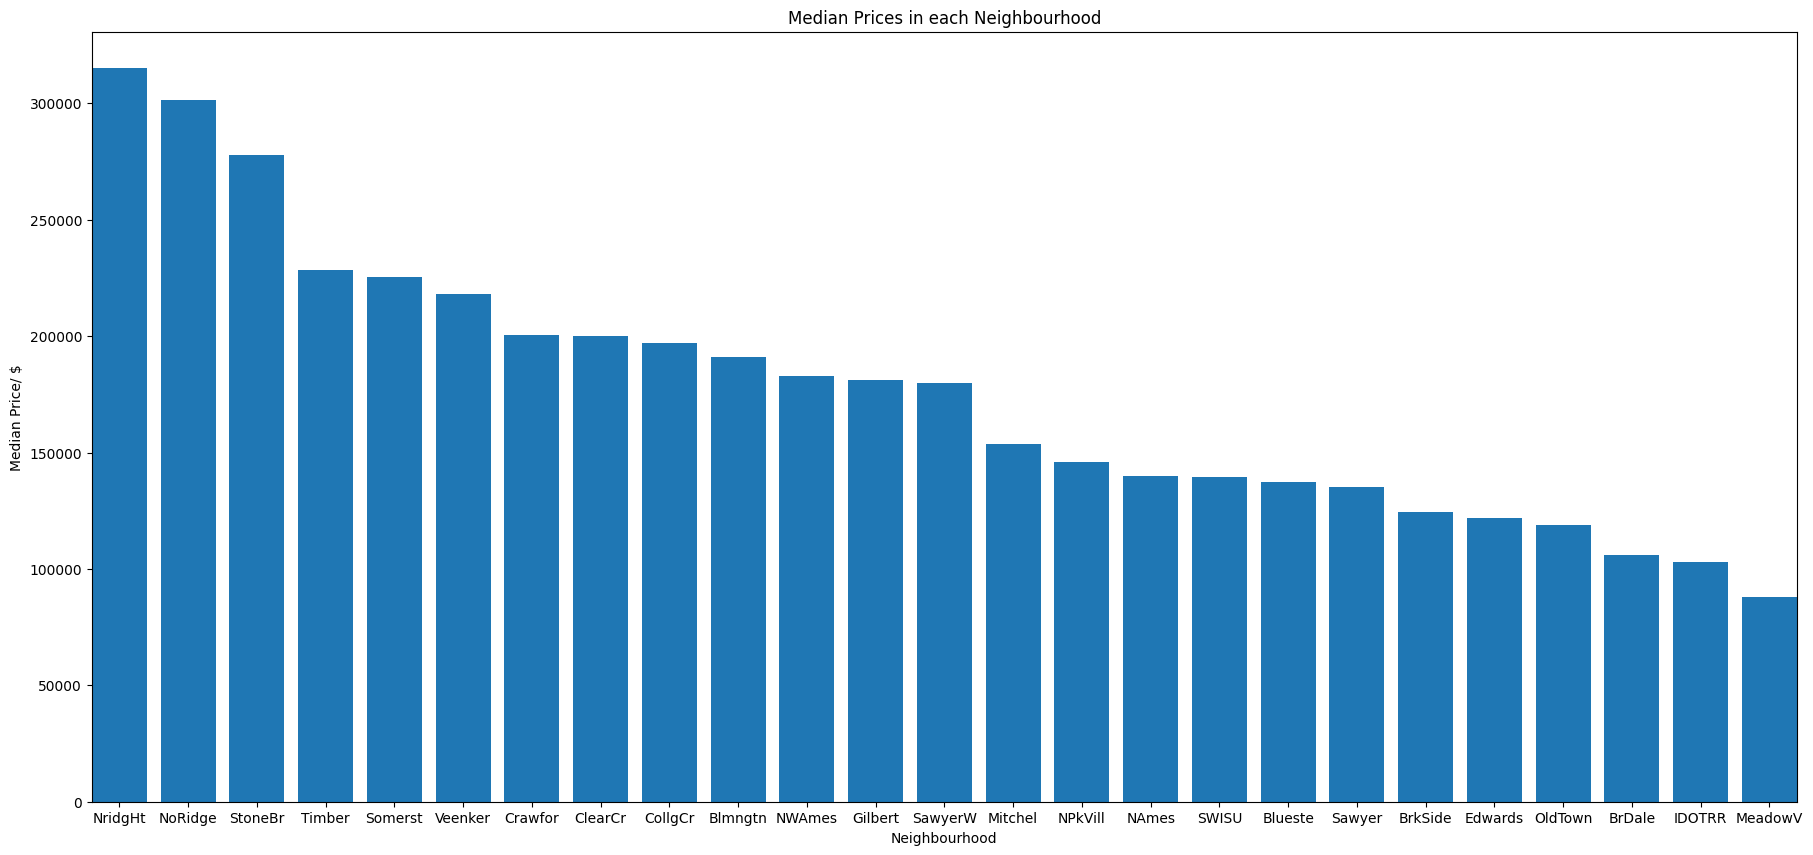

In [ ]:
#Neighbourhood
price_by_neighbourhood=train[['SalePrice','Neighborhood']]
price_by_neighbourhood=price_by_neighbourhood.groupby(['Neighborhood']).median()
price_by_neighbourhood = price_by_neighbourhood.sort_values('SalePrice', ascending=False)
plt.figure(figsize=(22,10))
plt.bar(price_by_neighbourhood.index, price_by_neighbourhood['SalePrice'])
plt.ylabel("Median Price/ $")
plt.xlabel("Neighbourhood")
plt.title("Median Prices in each Neighbourhood")
plt.margins(x=0)

Text(0.5, 0, 'Neighborhood')

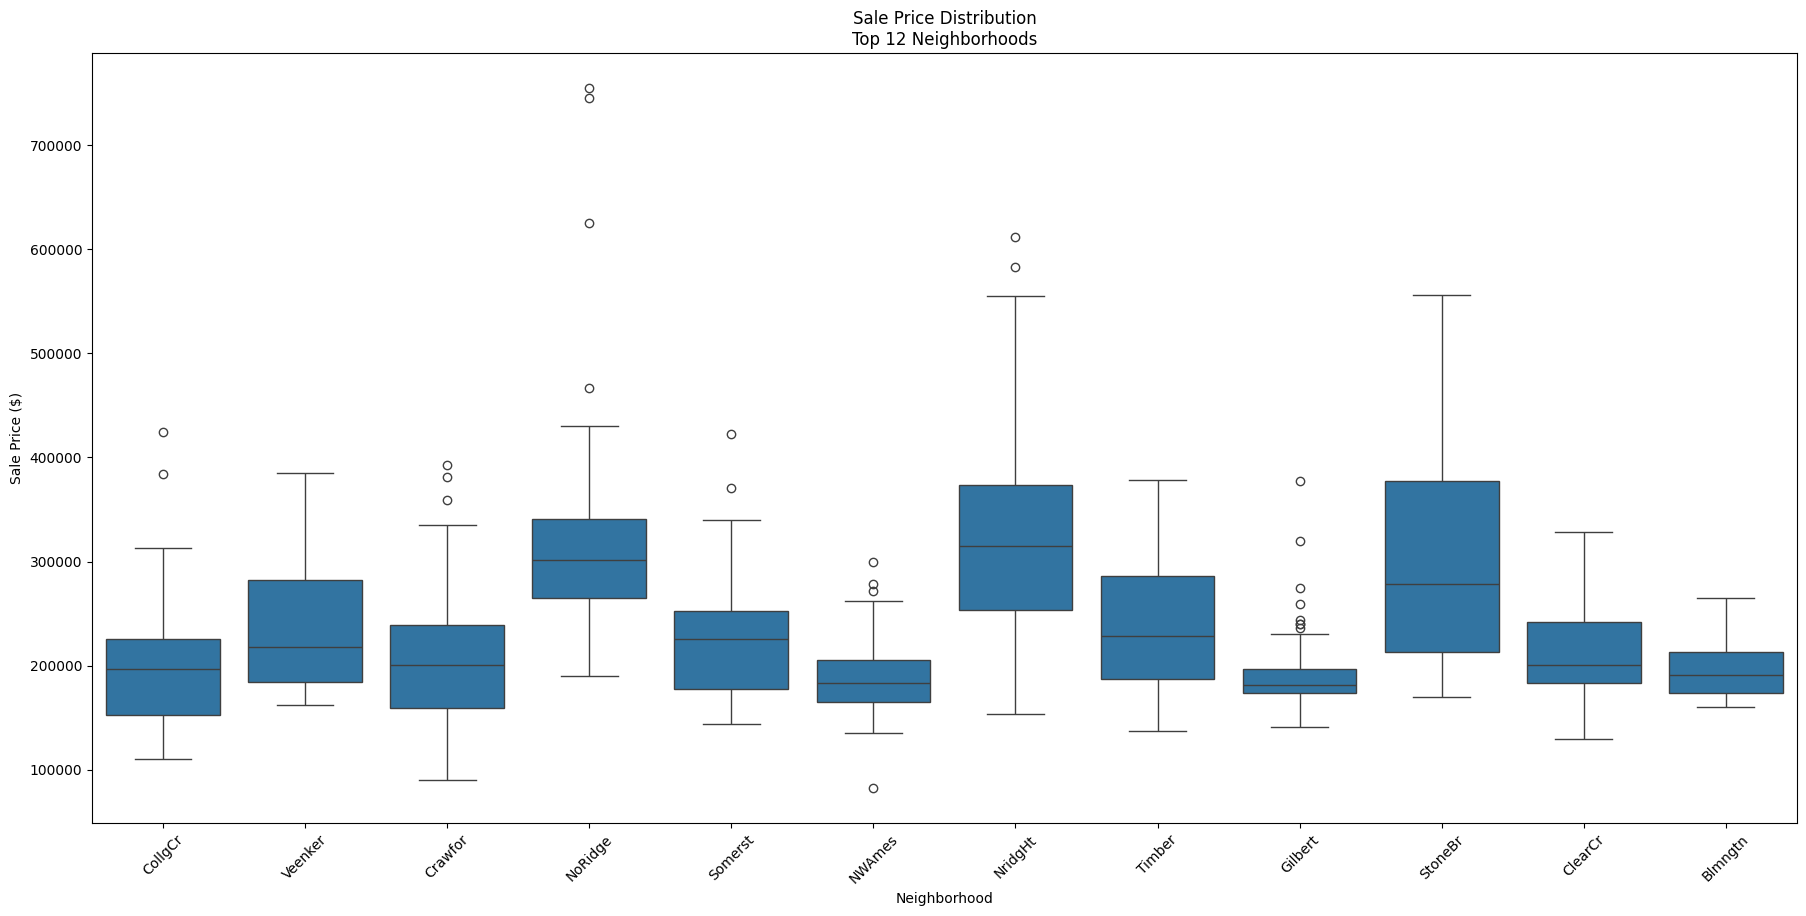

In [ ]:
#Sale Price By Neighbourhood Boxplot

#salesprice grouped by neighborhood
# price_by_neighbourhood=train[['SalePrice','Neighborhood']]
# #price by neighboorhood in acending order
# price_by_neighbourhood=price_by_neighbourhood.groupby(['Neighborhood']).median()
# price_by_neighbourhood = price_by_neighbourhood.sort_values('SalePrice', ascending=False)
# price_by_neighbourhood = price_by_neighbourhood.head(12)
# #boxplot with dimensions 22,10
# plt.figure(figsize=(22,10))
# plt.boxplot(price_by_neighbourhood.index, price_by_neighbourhood)
# plt.ylabel("Median Price/ $")
# plt.xlabel("Neighbourhood")
# plt.title("Median Prices in each Neighbourhood")
import seaborn as sns

top12_neigh = price_by_neighbourhood.sort_values('SalePrice', ascending=False).head(12).index
top12 = train[train['Neighborhood'].isin(top12_neigh)]

plt.figure(figsize=(22,10))
sns.boxplot(data=top12, x="Neighborhood", y="SalePrice")
plt.xticks(rotation=45)
plt.title("Sale Price Distribution\nTop 12 Neighborhoods")
plt.ylabel("Sale Price ($)")
plt.xlabel("Neighborhood")


# train.sample(10).boxplot(by='Neighborhood', column=['SalePrice'])

# plt.ylabel('Neighborhood')

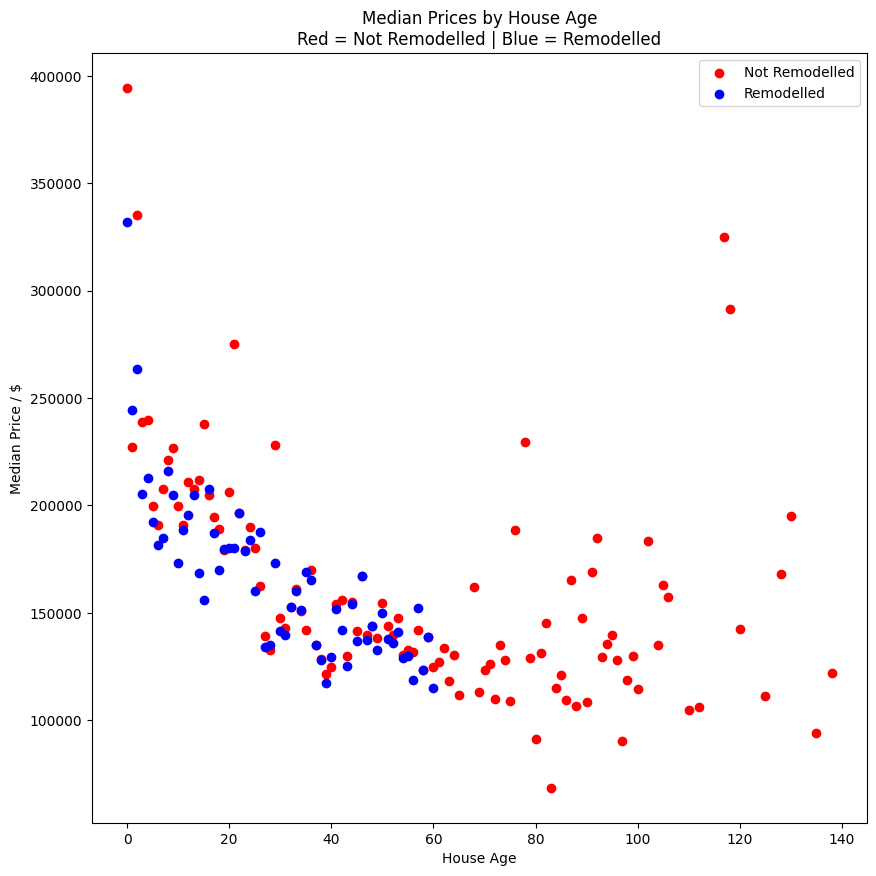

In [ ]:
# Sale Price By House Age (Modelled, Or Remodelled) scatterplot
plt.figure(figsize=(10,10))
train['HouseAge'] = 2010 - train['YearBuilt']
price_by_build_age = train[["SalePrice","HouseAge"]].groupby('HouseAge').median()
price_by_build_age.sort_values('HouseAge', ascending=False)

#built age (red)
plt.scatter(
    price_by_build_age.index,
    price_by_build_age['SalePrice'],
    color='red',
    label='Not Remodelled'
)

train['HouseAgeSinceRemodel'] = 2010 - train['YearRemodAdd']
price_by_remod_age = train[["SalePrice","HouseAgeSinceRemodel"]].groupby('HouseAgeSinceRemodel').median()
price_by_remod_age.sort_values("HouseAgeSinceRemodel", ascending=False)

#remodel age (blue)
plt.scatter(
    price_by_remod_age.index,
    price_by_remod_age["SalePrice"],
    color="blue",
    label='Remodelled'
)

plt.ylabel("Median Price / $")
plt.xlabel("House Age")
plt.title("Median Prices by House Age\nRed = Not Remodelled | Blue = Remodelled")
plt.legend()
columns_to_drop = ['HouseAge', 'HouseAgeSinceRemodel']
train.drop(columns=columns_to_drop, inplace=True)



# Models

## LASSO

In [ ]:
#base model and search grid for alpha (penalty strength)
lasso = make_pipe(Lasso(random_state=341, max_iter=10000))
#20 possible values of the penalty strength (α) from 0.0001 to 10, spaced logarithmically.
alpha_grid = np.logspace(-4, 1, 20)

#5-fold cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=341)

#grid search over alpha values (lower is better)
search = GridSearchCV(lasso, param_grid={"ttr__regressor__alpha": alpha_grid}, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)

search.fit(X_train, y_train)

#best model and results
best_lasso = search.best_estimator_
pred=best_lasso.predict(X_test)
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': pred})
submission.to_csv('/content/lassoSubmission.csv', index=False)

## RIDGE

In [ ]:
#base model and search grid for alpha (penalty strength)
ridge = make_pipe(Ridge(random_state=341, max_iter=10000))
#20 possible values of the penalty strength (α) from 0.0001 to 10, spaced logarithmically.
alpha_grid = np.logspace(-4, 1, 20)

#5-fold cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=341)

#grid search over alpha values (lower is better)
search = GridSearchCV(ridge, param_grid={"ttr__regressor__alpha": alpha_grid}, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)

search.fit(X_train, y_train)

#best model and results
best_ridge = search.best_estimator_
pred=best_ridge.predict(X_test)
#Submission
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': pred})
submission.to_csv('/content/ridgeSubmission.csv', index=False)



## RANDOM FOREST

In [ ]:
rfr=make_pipe(RandomForestRegressor(n_estimators=3, max_depth=8, random_state=341))
rfr.fit(X_train, y_train)

pred=rfr.predict(X_test)
#Submission
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': pred})
submission.to_csv('/content/rfrSubmission.csv', index=False)

## Decision Tree

In [ ]:
dt = make_pipe(DecisionTreeRegressor(random_state=341))

dt_params = {
    "ttr__regressor__max_depth": [5, 10, 15, 20, None],
    "ttr__regressor__min_samples_split": [2, 5, 10],
    "ttr__regressor__min_samples_leaf": [1, 2, 4]
}

search_dt = GridSearchCV(dt, param_grid=dt_params,
                        scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
search_dt.fit(X_train, y_train)

best_dt = search_dt.best_estimator_
pred=best_dt.predict(X_test)
#Submission
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': pred})
submission.to_csv('/content/dtSubmission.csv', index=False)

# Histograms
Some histograms were included in the presentation. They are all here

Text(0.5, 1.0, 'Distribution of Overall Quality')

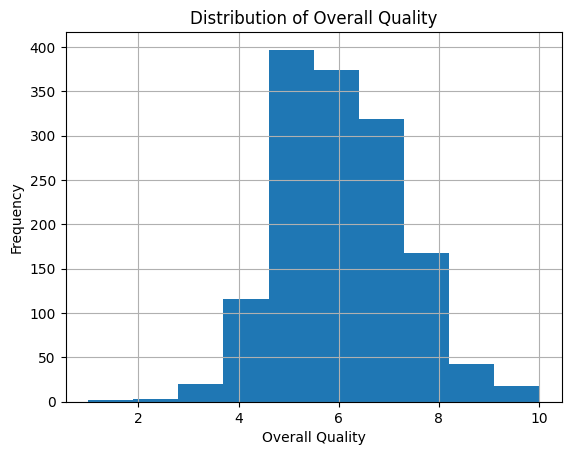

In [ ]:
train["OverallQual"].hist()
plt.ylabel("Frequency")
plt.xlabel("Overall Quality")
plt.title("Distribution of Overall Quality")

Text(0.5, 1.0, 'Distribution of Linear Square feet Connected to Property')

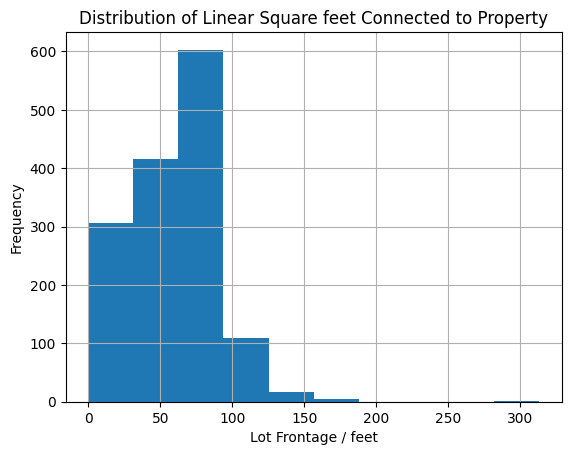

In [ ]:
train["LotFrontage"].hist()
plt.ylabel("Frequency")
plt.xlabel("Lot Frontage / feet")
plt.title("Distribution of Linear Square feet Connected to Property")
